<a href="https://colab.research.google.com/github/samuel127jules/es22452/blob/main/Lab6ES2245.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

data = {
    'Land_Cover': ['Forest']*20 + ['Grassland']*20 + ['Shrubland']*20,
    'Season': (['Wet']*10 + ['Dry']*10) * 3,
    'NDVI': [
        # Forest: High and Stable (Wet: ~0.85, Dry: ~0.82)
        0.86, 0.84, 0.88, 0.85, 0.83, 0.87, 0.85, 0.86, 0.84, 0.85, # Wet
        0.81, 0.83, 0.80, 0.82, 0.84, 0.81, 0.82, 0.83, 0.80, 0.82, # Dry
        # Grassland: Highly Seasonal (Wet: ~0.65, Dry: ~0.25)
        0.62, 0.68, 0.65, 0.61, 0.66, 0.64, 0.67, 0.63, 0.65, 0.64, # Wet
        0.22, 0.28, 0.25, 0.21, 0.26, 0.24, 0.27, 0.23, 0.25, 0.24, # Dry
        # Shrubland: Moderate Decline (Wet: ~0.50, Dry: ~0.35)
        0.51, 0.48, 0.52, 0.49, 0.50, 0.53, 0.47, 0.51, 0.49, 0.50, # Wet
        0.34, 0.38, 0.35, 0.31, 0.36, 0.34, 0.37, 0.33, 0.35, 0.34  # Dry
    ]
}

df = pd.DataFrame(data)
print("Dataset Preview:")
print(df.head())

Dataset Preview:
  Land_Cover Season  NDVI
0     Forest    Wet  0.86
1     Forest    Wet  0.84
2     Forest    Wet  0.88
3     Forest    Wet  0.85
4     Forest    Wet  0.83


In [4]:
# HINT: The formula syntax is 'Dependent_Var ~ C(Factor1) * C(Factor2)'
# The '*' tells Python to calculate both main effects AND the interaction.

model_formula = 'NDVI ~ C(Land_Cover) * C(Season)'

model = ols(model_formula, data=df).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                          sum_sq    df            F        PR(>F)
C(Land_Cover)            2.15131   2.0  3109.495182  1.749109e-56
C(Season)                0.57624   1.0  1665.790150  2.865520e-42
C(Land_Cover):C(Season)  0.34693   2.0   501.451285  1.335635e-35
Residual                 0.01868  54.0          NaN           NaN


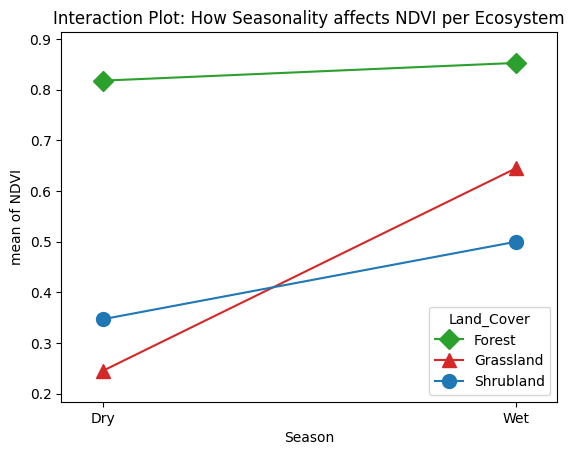

In [5]:
from statsmodels.graphics.factorplots import interaction_plot

fig = interaction_plot(x=df['Season'],
                        trace=df['Land_Cover'],
                        response=df['NDVI'],
                        colors=['#2ca02c', '#d62728', '#1f77b4'],
                        markers=['D', '^', 'o'], ms=10)

plt.title('Interaction Plot: How Seasonality affects NDVI per Ecosystem')
plt.show()


**QUESTION: Are the lines parallel? What does this imply about the interaction?**

The lines are not parallel meaning there is significant interaction between "season" and "land cover".

In [12]:
df['Group'] = df['Land_Cover'] + "_" + df['Season']

# HINT: Use pairwise_tukeyhsd(endog=df['Column'], groups=df['Group_Column'])

tukey_results = pairwise_tukeyhsd(endog=df['NDVI'], groups=df['Group'])
print(tukey_results)

print(tukey_results.summary())

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
   Forest_Dry    Forest_Wet    0.035 0.0013  0.0104  0.0596   True
   Forest_Dry Grassland_Dry   -0.573    0.0 -0.5976 -0.5484   True
   Forest_Dry Grassland_Wet   -0.173    0.0 -0.1976 -0.1484   True
   Forest_Dry Shrubland_Dry   -0.471    0.0 -0.4956 -0.4464   True
   Forest_Dry Shrubland_Wet   -0.318    0.0 -0.3426 -0.2934   True
   Forest_Wet Grassland_Dry   -0.608    0.0 -0.6326 -0.5834   True
   Forest_Wet Grassland_Wet   -0.208    0.0 -0.2326 -0.1834   True
   Forest_Wet Shrubland_Dry   -0.506    0.0 -0.5306 -0.4814   True
   Forest_Wet Shrubland_Wet   -0.353    0.0 -0.3776 -0.3284   True
Grassland_Dry Grassland_Wet      0.4    0.0  0.3754  0.4246   True
Grassland_Dry Shrubland_Dry    0.102    0.0  0.0774  0.1266   True
Grassland_Dry Shrubland_Wet    0.255    0.0  0.2304  0.2796   

In [23]:
zones = ['Continuous', 'Discontinuous']
sites_per_zone = ['Site_A', 'Site_B', 'Site_C']
n_cores = 10

nested_data = []
for z in zones:
    for s in sites_per_zone:
        site_mean = np.random.uniform(10, 20) if z == 'Continuous' else np.random.uniform(5, 12)
        samples = np.random.normal(site_mean, 1.5, n_cores)
        for val in samples:
            nested_data.append({'Zone': z, 'Site': s, 'SOC': val})

df_nested = pd.DataFrame(nested_data)

nested_model_formula = 'SOC ~ C(Zone) + C(Zone):C(Site)'
nested_model = ols(nested_model_formula, data=df_nested).fit()

print(sm.stats.anova_lm(nested_model, typ=2))

                     sum_sq    df           F        PR(>F)
C(Zone)          290.941405   1.0  119.877764  2.506682e-15
C(Zone):C(Site)  147.573994   4.0   15.201377  2.189458e-08
Residual         131.057132  54.0         NaN           NaN


In [25]:
satellites = ['ICESat-2', 'CryoSat-2', 'Sentinel-6']
sites = ['Greenland_1', 'Antarctica_A', 'Himalaya_Main', 'Andes_High', 'Alps_Ref']

no_rep_data = []
for sat in satellites:
    for site in sites:
        error = np.random.uniform(2, 5) + np.random.randint(1, 4)
        no_rep_data.append({'Satellite': sat, 'Site': site, 'Error': error})

df_no_rep = pd.DataFrame(no_rep_data)

no_rep_model = ols('Error ~ C(Satellite) + C(Site)', data=df_no_rep).fit()

print(sm.stats.anova_lm(no_rep_model, typ=2))

                 sum_sq   df         F    PR(>F)
C(Satellite)   0.395058  2.0  0.084147  0.920098
C(Site)        0.822002  4.0  0.087543  0.983843
Residual      18.779317  8.0       NaN       NaN


**1. Model Selection: In the Satellite Altimeter study (Module 6), why were we unable to test for an interaction between Satellite and Site?**

The data does not allow for any replication, so we are unable to test for their interaction (Sattelite and Site). We would need multiple points to see if it is an interaction thing or random noise.

**2. Degrees of Freedom: Look at the ANOVA table for the Two-Way ANOVA with replication (Module 2). How did the number of samples (
 per group) affect the Degrees of Freedom (
) compared to the "without replication" model?**

In the two-way ANOVA with replication, there are multiple observations, or samples, so these would allow you to see if there is more variability within the samples or random noise, this has a proportional increase in degrees of freedom and samples. In the two-way ANOVA without replication, there is only one observation which limits the degrees of freedom.

**3. Geoscientific Context: If you were studying earthquake magnitudes across different Fault Types and Depth Ranges, would you use a Nested design or a Two-Factor Factorial design? Why?**


A Two-Factor Factorial design would be better because both "Fault Types" and "Depth Ranges" are independent variables that influence the outcome, earthquake magnitudes. A nested would make sense if the depth ranges and fault types were specificed.  